# 3.2 Heat conduction in a square metal

## Environment configuration

CPU: 13th Gen Intel(R) Core(TM) i7-13700K 64GB

python==3.13.9 torch==2.9.1

In [1]:
import torch
from cibsde import nn, utils
import matplotlib.pyplot as plt
device = 'cpu'
seed = 666
torch.manual_seed(seed)

## Parameter settings

In [2]:
# model parameters
d = 2
t = torch.tensor([0.25,0.5,0.75,1],device=device)
D = torch.tensor(0.5,device=device)
N = [25,50,75,100]
# training parameters
batch = 512
epoch = 10**4
lr = 1e-3
train_params = {
    'epoch': epoch,
    'batch': batch,
    'lr': lr
}

## Model initialization

In [3]:
def data_gen(batch):
    return torch.rand([batch,2],device=device)*torch.pi*2

def pc(i,x):
    return (torch.sin(x[:,:1])+1)*(torch.cos(x[:,1:])+1)

def refb(x):
    in_ornot = (x[:,0]>0) * (x[:,0]<torch.pi*2) * (x[:,1]>0) * (x[:,1]<torch.pi*2)
    left = (x[:,:1] - 0).abs()
    right = (x[:,:1] - torch.pi*2).abs()
    on = (x[:,1:] - 0).abs()
    down = (x[:,1:] - torch.pi*2).abs()
    b_min = torch.argmin(torch.cat([left,right,on,down],dim=1),dim=1)
    xb_ = x.clone()
    n = torch.zeros_like(x).to(device)
    xb_[(b_min==0)*in_ornot,0] = 0
    xb_[(b_min==1)*in_ornot,0] = torch.pi*2
    xb_[(b_min==2)*in_ornot,1] = 0
    xb_[(b_min==3)*in_ornot,1] = torch.pi*2
    xb_[((x[:,0]<=0)*(x[:,1]<=0))] = torch.tensor([0,0]).float().to(device)
    xb_[((x[:,0]<=0)*(x[:,1]>=torch.pi*2))] = torch.tensor([0,torch.pi*2]).float().to(device)
    xb_[((x[:,0]>=torch.pi*2)*(x[:,1]<=0))] = torch.tensor([torch.pi*2,0]).float().to(device)
    xb_[((x[:,0]>=torch.pi*2)*(x[:,1]>=torch.pi*2))] = torch.tensor([torch.pi*2,torch.pi*2]).float().to(device)
    xb_[((x[:,0]<=0)*(x[:,1]>0)*(x[:,1]<torch.pi*2)),0] = 0
    xb_[((x[:,0]>=torch.pi*2)*(x[:,1]>0)*(x[:,1]<torch.pi*2)),0] = torch.pi*2
    xb_[((x[:,1]<=0)*(x[:,0]>0)*(x[:,0]<torch.pi*2)),1] = 0
    xb_[((x[:,1]>=torch.pi*2)*(x[:,0]>0)*(x[:,0]<torch.pi*2)),1] = torch.pi*2
    n[(b_min==0)*in_ornot,0] = -1
    n[(b_min==1)*in_ornot,0] = 1
    n[(b_min==2)*in_ornot,1] = -1
    n[(b_min==3)*in_ornot,1] = 1
    n[((x[:,0]<=0)*(x[:,1]>0)*(x[:,1]<torch.pi*2)),0] = -1
    n[((x[:,0]>=torch.pi*2)*(x[:,1]>0)*(x[:,1]<torch.pi*2)),0] = 1
    n[((x[:,1]<=0)*(x[:,0]>0)*(x[:,0]<torch.pi*2)),1] = -1
    n[((x[:,1]>=torch.pi*2)*(x[:,0]>0)*(x[:,0]<torch.pi*2)),1] = 1
    n[((x[:,0]<=0)*(x[:,1]<=0))] = torch.sqrt(torch.tensor([1/2,1/2]).to(device))*(-1)
    n[((x[:,0]<=0)*(x[:,1]>=torch.pi*2))] = torch.sqrt(torch.tensor([1/2,1/2]).to(device))*torch.tensor([-1,1]).to(device)
    n[((x[:,0]>=torch.pi*2)*(x[:,1]<=0))] = torch.sqrt(torch.tensor([1/2,1/2]).to(device))*torch.tensor([1,-1]).to(device)
    n[((x[:,0]>=torch.pi*2)*(x[:,1]>=torch.pi*2))] = torch.sqrt(torch.tensor([1/2,1/2]).to(device))*torch.tensor([1,1]).to(device)
    return xb_, n, ~in_ornot

def hitb(x):
    return torch.zeros(batch,device=device).bool()

def f(t,xt,p,grad_p):
    return torch.zeros([batch,1],device=device)

def h(t,xt):
    res = torch.zeros([xt.shape[0],1],device=device)
    res[xt[:,0] == 0] = 1
    res[xt[:,0] == torch.pi*2] = -1
    res[xt[:,1] == 0] = 0
    res[xt[:,1] == torch.pi*2] = 0
    return res

def mu(t,xt):
    return torch.zeros([batch,d],device=device)

def sigma(t,xt):
    return torch.eye(d,device=device).expand([batch,d,d]).clone()*torch.sqrt(2*D)

models = [nn.BoundaryIBSDE(
    d = d,
    t = t[i],
    f = f,
    mu = mu,
    sigma = sigma,
    h = h,
    pc = pc,
    data_gen = data_gen,
    N = N[i],
    refb = refb,
    hitb = hitb,
    param = False
).to(device) for i in range(4)]

## Model training

In [4]:
loss_values = [nn.train(
    model,
    train_params
) for model in models]

100%|██████████| 10000/10000 [07:44<00:00, 21.52it/s, loss=1.644894e-02]



Training has been completed.


100%|██████████| 10000/10000 [14:23<00:00, 11.58it/s, loss=2.573577e-02]



Training has been completed.


100%|██████████| 10000/10000 [20:35<00:00,  8.10it/s, loss=2.737107e-02]



Training has been completed.


100%|██████████| 10000/10000 [25:44<00:00,  6.47it/s, loss=3.917475e-02]


Training has been completed.


## PINN

In [5]:
class PINN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.p = utils.FNN(3,1)
    
    def forward(self, batch):
        x = torch.rand([batch,2],requires_grad=True,device=device)*2*torch.pi
        t = torch.rand([batch,1],requires_grad=True,device=device)
        xb_ = (torch.sign(torch.randn([batch,2],device=device))*1.1 + 1)*torch.pi
        tb = torch.rand([batch,1],device=device)
        xT = torch.rand([batch,2],requires_grad=True,device=device)*2*torch.pi
        T = torch.ones([batch,1],device=device)
        u = self.p(torch.cat([t,x],dim=1))
        grad_u = torch.autograd.grad(u,x,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
        grad_u1 = torch.autograd.grad(grad_u[:,:1],x,torch.ones_like(grad_u[:,:1]),retain_graph=True,create_graph=True)[0][:,:1]
        grad_u2 = torch.autograd.grad(grad_u[:,1:],x,torch.ones_like(grad_u[:,1:]),retain_graph=True,create_graph=True)[0][:,1:]
        ut = torch.autograd.grad(u,t,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
        xb, nb, _ = refb(xb_)
        xb.requires_grad = True
        ub = self.p(torch.cat([tb,xb],dim=1))
        grad_ub = torch.autograd.grad(ub,xb,torch.ones_like(ub),retain_graph=True,create_graph=True)[0]
        grad_ub = (grad_ub*nb).sum(dim=1,keepdim=True)
        hb = h(tb,xb)
        uT = self.p(torch.cat([T,xT],dim=1))
        return torch.cat([ut,grad_ub,uT]), torch.cat([-D*(grad_u1+grad_u2),hb,pc(100,xT)])

## PINN initialization

In [6]:
pinn = PINN().to(device)

## PINN training

In [7]:
loss_value_pinn = nn.train(
    pinn,
    train_params
)

100%|██████████| 10000/10000 [01:24<00:00, 118.82it/s, loss=3.497783e-03]


Training has been completed.


## Loading reference solution

In [8]:
y_rel = torch.load('./datasets/example2.pth')

## Plot figures

In [9]:
grid = 10**2+1
k = 3
x = torch.linspace(0,torch.pi*2,grid)
x1, x2 = torch.meshgrid(x,x,indexing='ij')
x = torch.cat([x1.reshape([grid**2,1]),x2.reshape([grid**2,1])],dim=1)
tt = torch.ones([4,grid**2,1]) * (1-t[:,None,None])
y_pinn = [pinn.p(torch.cat([tt[i],x],dim=1).to(device))[:,0].cpu().detach().reshape(grid,grid) for i in range(4)]
y_pre = [model.p(x.to(device)[:,None])[:,0].cpu().detach().reshape(grid,grid) for model in models]

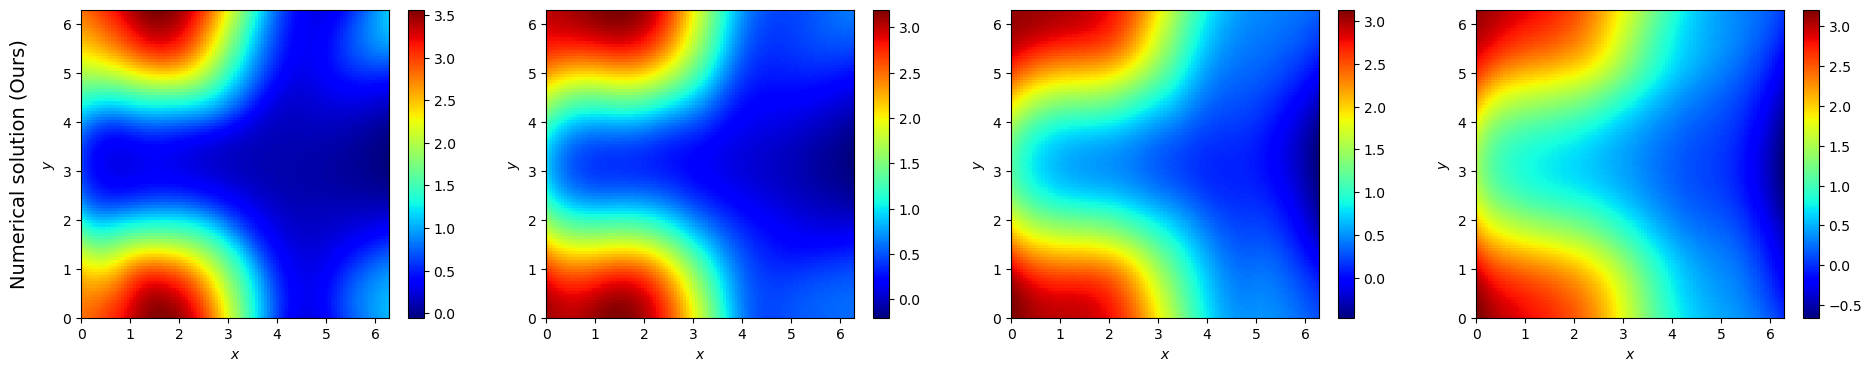

In [10]:
plt.figure(figsize=(23,4))
plt.subplot(1,4,1)
plt.text(-0.2, 0.5, 'Numerical solution (Ours)', transform=plt.gca().transAxes, rotation=90, fontsize=14, va='center', ha='center')
plt.imshow(y_pre[0].T, cmap='jet', origin='lower', extent=[0, torch.pi*2, 0, torch.pi*2])
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.subplot(1,4,2)
plt.imshow(y_pre[1].T, cmap='jet', origin='lower', extent=[0, torch.pi*2, 0, torch.pi*2])
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.subplot(1,4,3)
plt.imshow(y_pre[2].T, cmap='jet', origin='lower', extent=[0, torch.pi*2, 0, torch.pi*2])
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.subplot(1,4,4)
plt.imshow(y_pre[3].T, cmap='jet', origin='lower', extent=[0, torch.pi*2, 0, torch.pi*2])
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('./figures/euclid_cibsde.pdf', bbox_inches='tight', dpi=2000, format='pdf')
plt.show()

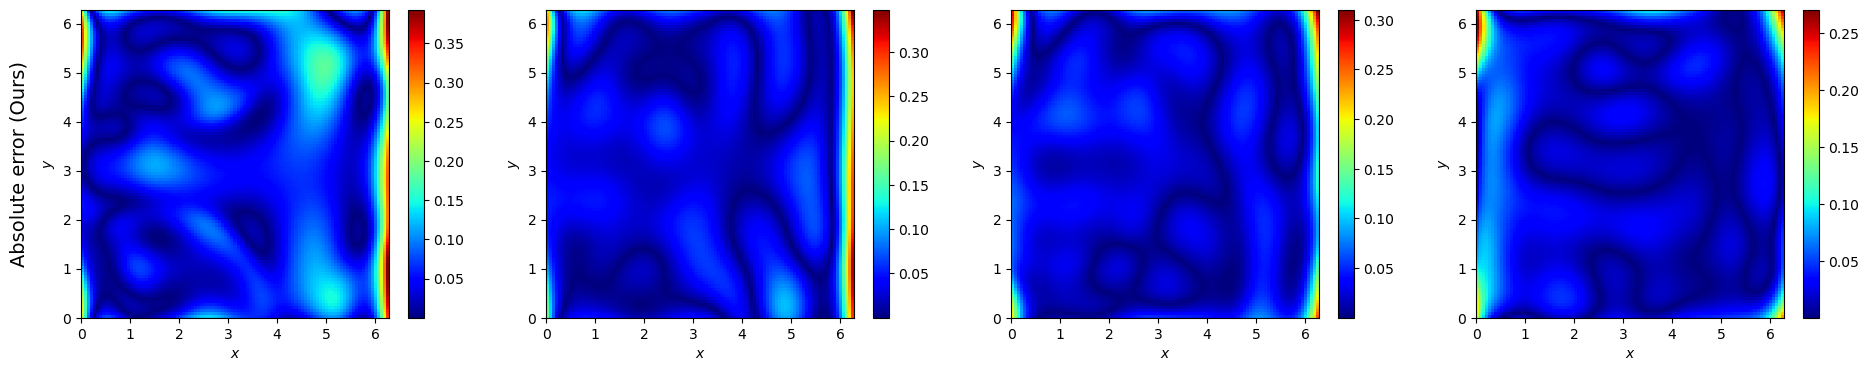

In [11]:
plt.figure(figsize=(23,4))
plt.subplot(1,4,1)
plt.text(-0.2, 0.5, 'Absolute error (Ours)', transform=plt.gca().transAxes, rotation=90, fontsize=14, va='center', ha='center')
plt.imshow((y_pre[0]-y_rel[0]).abs().T, cmap='jet', origin='lower', extent=[0, torch.pi*2, 0, torch.pi*2])
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.subplot(1,4,2)
plt.imshow((y_pre[1]-y_rel[1]).abs().T, cmap='jet', origin='lower', extent=[0, torch.pi*2, 0, torch.pi*2])
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.subplot(1,4,3)
plt.imshow((y_pre[2]-y_rel[2]).abs().T, cmap='jet', origin='lower', extent=[0, torch.pi*2, 0, torch.pi*2])
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.subplot(1,4,4)
plt.imshow((y_pre[3]-y_rel[3]).abs().T, cmap='jet', origin='lower', extent=[0, torch.pi*2, 0, torch.pi*2])
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('./figures/euclid_cibsde_err.pdf', bbox_inches='tight', dpi=2000, format='pdf')
plt.show()

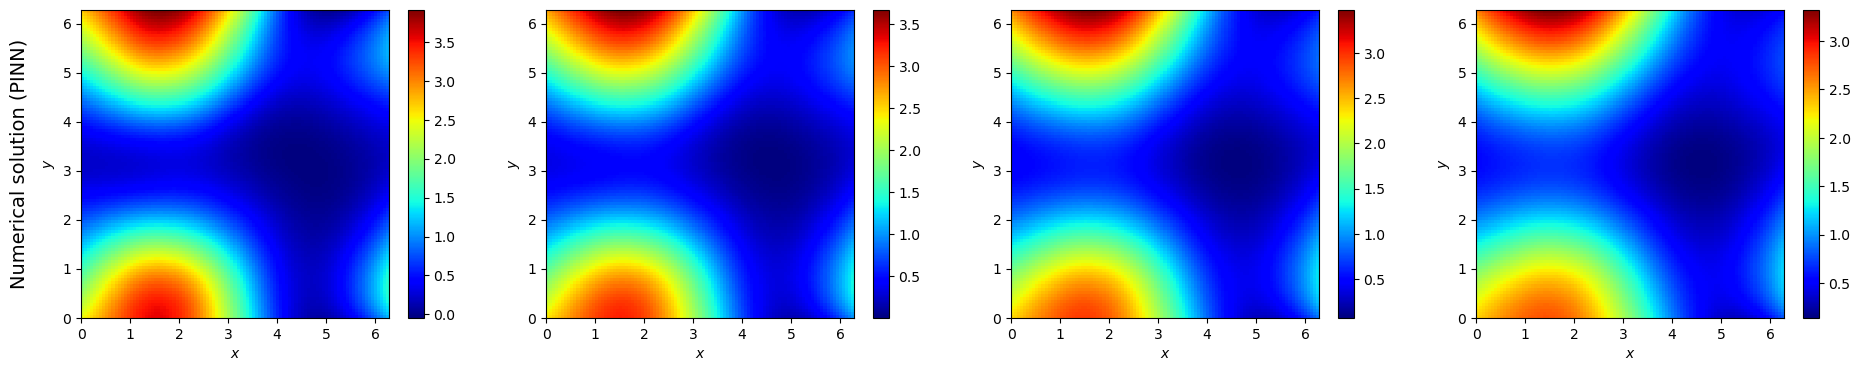

In [12]:
plt.figure(figsize=(23,4))
plt.subplot(1,4,1)
plt.text(-0.2, 0.5, 'Numerical solution (PINN)', transform=plt.gca().transAxes, rotation=90, fontsize=14, va='center', ha='center')
plt.imshow(y_pinn[0].T, cmap='jet', origin='lower', extent=[0, torch.pi*2, 0, torch.pi*2])
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.subplot(1,4,2)
plt.imshow(y_pinn[1].T, cmap='jet', origin='lower', extent=[0, torch.pi*2, 0, torch.pi*2])
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.subplot(1,4,3)
plt.imshow(y_pinn[2].T, cmap='jet', origin='lower', extent=[0, torch.pi*2, 0, torch.pi*2])
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.subplot(1,4,4)
plt.imshow(y_pinn[3].T, cmap='jet', origin='lower', extent=[0, torch.pi*2, 0, torch.pi*2])
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('./figures/euclid_pinn.pdf', bbox_inches='tight', dpi=2000, format='pdf')
plt.show()

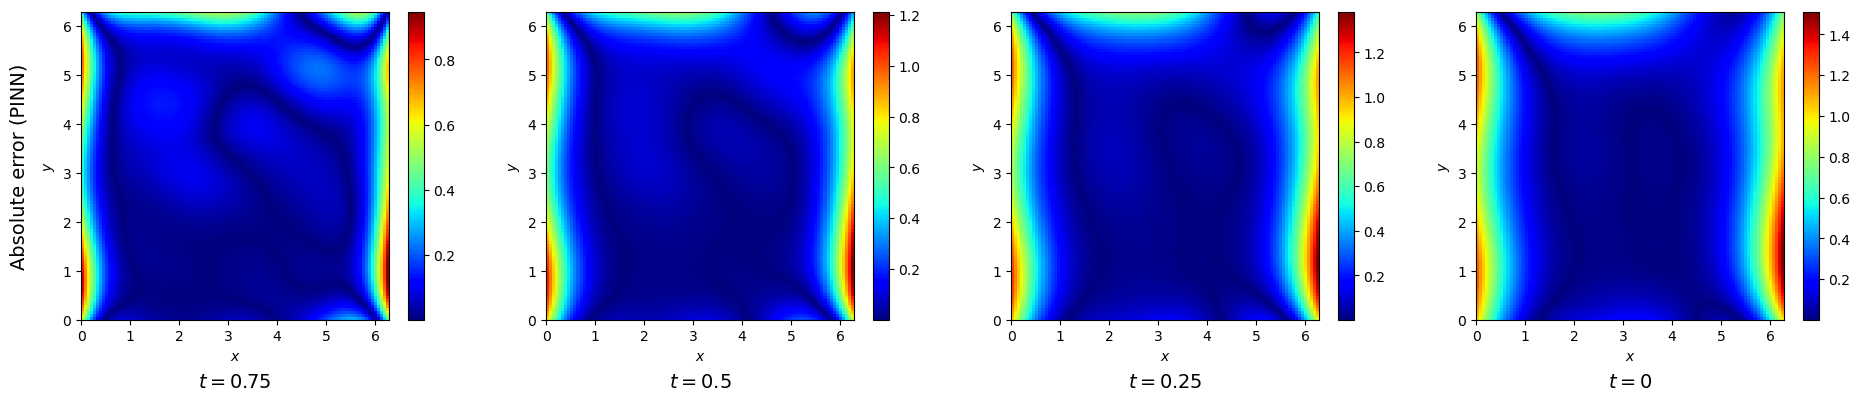

In [13]:
plt.figure(figsize=(23,4))
plt.subplot(1,4,1)
plt.text(-0.2, 0.5, 'Absolute error (PINN)', transform=plt.gca().transAxes, rotation=90, fontsize=14, va='center', ha='center')
plt.imshow((y_pinn[0]-y_rel[0]).abs().T, cmap='jet', origin='lower', extent=[0, torch.pi*2, 0, torch.pi*2])
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.text(
    0.5, -0.2, '$t=0.75$', 
    transform=plt.gca().transAxes,
    fontsize=14,
    va='center',
    ha='center'
)
plt.subplot(1,4,2)
plt.imshow((y_pinn[1]-y_rel[1]).abs().T, cmap='jet', origin='lower', extent=[0, torch.pi*2, 0, torch.pi*2])
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.text(
    0.5, -0.2, '$t=0.5$', 
    transform=plt.gca().transAxes,
    fontsize=14,
    va='center',
    ha='center'
)
plt.subplot(1,4,3)
plt.imshow((y_pinn[2]-y_rel[2]).abs().T, cmap='jet', origin='lower', extent=[0, torch.pi*2, 0, torch.pi*2])
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.text(
    0.5, -0.2, '$t=0.25$', 
    transform=plt.gca().transAxes,
    fontsize=14,
    va='center',
    ha='center'
)
plt.subplot(1,4,4)
plt.imshow((y_pinn[3]-y_rel[3]).abs().T, cmap='jet', origin='lower', extent=[0, torch.pi*2, 0, torch.pi*2])
plt.colorbar()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.text(
    0.5, -0.2, '$t=0$', 
    transform=plt.gca().transAxes,
    fontsize=14,
    va='center',
    ha='center'
)
plt.savefig('./figures/euclid_pinn_err.pdf', bbox_inches='tight', dpi=2000, format='pdf')
plt.show()

In [14]:
exact_sum = torch.tensor([4*torch.pi**2]*4)
pinn_sum = torch.tensor([y_pinn[i][:100,:100].sum()*(torch.pi*2/100)**2 for i in range(4)])
cibsde_sum = torch.tensor([y_pre[i][:100,:100].sum()*(torch.pi*2/100)**2 for i in range(4)])

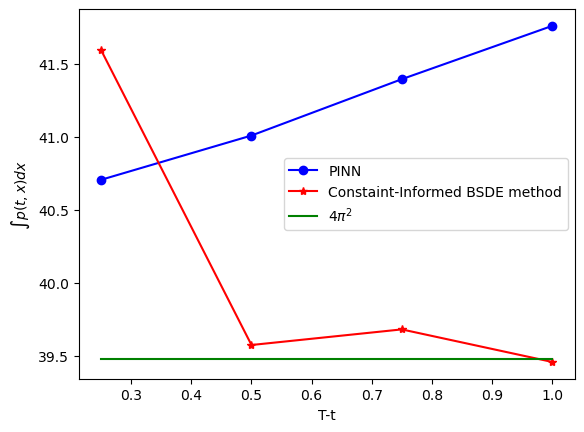

In [15]:
plt.plot(torch.linspace(0.25,1,4),pinn_sum,'o-',c='b',label='PINN')
plt.plot(torch.linspace(0.25,1,4),cibsde_sum,'*-',c='r',label='Constaint-Informed BSDE method')
plt.plot(torch.linspace(0.25,1,4),exact_sum,c='g',label=r'$4\pi^2$')
plt.xlabel('T-t')
plt.ylabel(r'$\int p(t,x)dx$')
plt.legend()
plt.savefig('./figures/energy.pdf',dpi=2000,format='pdf')
plt.show()

## Relative L2 errors

In [16]:
error_pinn = []
error_cibsde = []
for i in range(4):
    error_pinn.append(torch.sqrt(((y_pinn[i]-y_rel[i])**2).mean() / ((y_rel[i])**2).mean()))
    error_cibsde.append(torch.sqrt(((y_pre[i]-y_rel[i])**2).mean() / ((y_rel[i])**2).mean()))
print('Relative L2 errors \n', 'PINN: ', error_pinn, '\n', 'Ours: ', error_cibsde)

Relative L2 errors 
 PINN:  [tensor(0.1275), tensor(0.1915), tensor(0.2472), tensor(0.2963)] 
 Ours:  [tensor(0.0557), tensor(0.0415), tensor(0.0300), tensor(0.0266)]
